# UCI - Heart Disease Prediction

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
from google.colab import drive
drive.mount("/content/mydrive", force_remount=True)

Mounted at /content/mydrive


In [9]:
%cd /content/mydrive/MyDrive/Colab Notebooks/2026 - Client Projects/Heart Disease Prediction using UCI Dataset/UCI -Heart Disease Prediction - 3rd Milestone

/content/mydrive/MyDrive/Colab Notebooks/2026 - Client Projects/Heart Disease Prediction using UCI Dataset/UCI -Heart Disease Prediction - 3rd Milestone


In [10]:
project_path = "/content/mydrive/MyDrive/Colab Notebooks/2026 - Client Projects/Heart Disease Prediction using UCI Dataset/UCI -Heart Disease Prediction - 3rd Milestone/"

## Import and Understand Dataset (Coronary Heart Disease Dataset Description and Problem Understanding)

### Context

This dataset is a multivariate dataset, meaning it contains multiple independent variables used for statistical and machine learning analysis. It consists of 14 primary attributes that describe patient clinical and demographic information.

The dataset is widely used in machine learning research for cardiovascular disease prediction. The main objective is to determine whether a patient has heart disease based on input medical features. It is also used for exploratory analysis to identify patterns and relationships between clinical attributes and heart disease occurrence.

Among several available heart disease datasets, the Cleveland dataset is the most commonly used in machine learning studies due to its completeness and reliability.

---

## Objective of the Dataset

The primary task is:

To predict whether a patient has coronary heart disease based on clinical and demographic attributes.

This is a supervised learning classification problem where the model learns patterns from labeled patient data and predicts disease presence.

---

## Column Descriptions

#### 1. id
Unique identifier for each patient record.

---

#### 2. age
Age of the patient in years.

---

#### 3. origin
Location or place where the data was collected.

---

#### 4. sex
Gender of the patient:
- Male
- Female

---

#### 5. cp (Chest Pain Type)
Categorical variable describing type of chest pain:
- Typical angina
- Atypical angina
- Non-anginal pain
- Asymptomatic

---

#### 6. trestbps (Resting Blood Pressure)
Resting blood pressure measured in mm Hg at hospital admission.

---

#### 7. chol (Serum Cholesterol)
Serum cholesterol level measured in mg/dl.

---

#### 8. fbs (Fasting Blood Sugar)
Indicates whether fasting blood sugar is greater than 120 mg/dl:
- True
- False

---

#### 9. restecg (Resting Electrocardiographic Results)
Electrocardiogram results at rest:
- Normal
- ST-T wave abnormality
- Left ventricular hypertrophy

---

#### 10. thalach (Maximum Heart Rate Achieved)
Highest heart rate achieved during physical activity.

---

#### 11. exang (Exercise Induced Angina)
Indicates whether exercise causes angina:
- True
- False

---

#### 12. oldpeak
ST depression induced by exercise relative to rest. It indicates stress-induced heart changes.

---

#### 13. slope
Slope of the peak exercise ST segment:
- Upsloping
- Flat
- Downsloping

---

#### 14. ca (Number of Major Vessels)
Number of major blood vessels (0–3) colored by fluoroscopy.

---

#### 15. thal
Thalassemia blood disorder type:
- Normal
- Fixed defect
- Reversible defect

---

#### 16. num (Target Variable)
This is the predicted attribute representing the presence and severity of heart disease.

#### Values:
- 0: No heart disease
- 1: Mild heart disease
- 2: Moderate heart disease
- 3: Severe heart disease
- 4: Very severe heart disease

---

## Simplification for Machine Learning

For model building, the target variable is often converted into a binary classification problem:

- 0 → No heart disease
- 1 → Presence of heart disease (any level 1–4)

---

## Summary of Problem Statement

The goal of this study is to build a machine learning model that predicts coronary heart disease using patient clinical data. The system learns patterns from features such as age, cholesterol level, blood pressure, and chest pain type to classify whether a patient is at risk of heart disease.

This enables early detection and supports clinical decision-making in resource-limited healthcare environments.

In [ ]:
heart_disease_dataset_csv_path = "./Dataset/heart_disease_uci.csv"

In [ ]:
df = pd.read_csv(heart_disease_dataset_csv_path)
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## Data Visualization

#### TARGET DISTRIBUTION

/tmp/ipykernel_9331/403719299.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='num', data=df, palette=["orange", "skyblue", "lightblue", "cyan", "darkblue"])


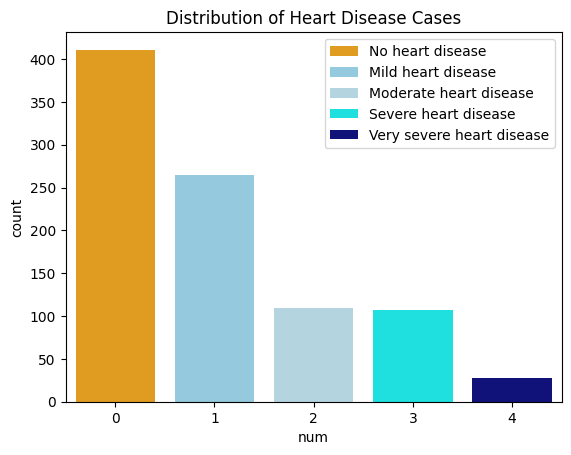

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='num', data=df, palette=["orange", "skyblue", "lightblue", "cyan", "darkblue"])
plt.title("Distribution of Heart Disease Cases")
plt.legend({"No heart disease": "red",
            "Mild heart disease": "",
            "Moderate heart disease": "",
            "Severe heart disease": "",
            "Very severe heart disease": ""},)
plt.show()

#### CONVERT TARGET TO BINARY

This converts the problem into a binary classification task where:

0 = No heart disease
1 = Presence of heart disease

This simplifies the prediction task and aligns with most clinical decision-support systems.

In [ ]:
df['target'] = df['num'].apply(lambda x: 0 if x == 0 else 1)

#### TARGET CLASS DISTRIBUTION (BINARY)

This shows the balance between healthy and diseased patients. If the dataset is imbalanced, it may affect model performance and require adjustment techniques.**bold text**

/tmp/ipykernel_9331/1644614970.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette=["orange", "skyblue", "lightblue", "cyan", "darkblue"])
/tmp/ipykernel_9331/1644614970.py:1: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.countplot(x='target', data=df, palette=["orange", "skyblue", "lightblue", "cyan", "darkblue"])


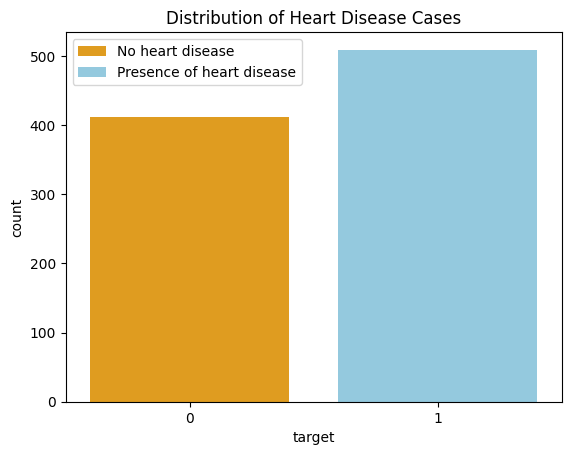

In [ ]:
sns.countplot(x='target', data=df, palette=["orange", "skyblue", "lightblue", "cyan", "darkblue"])
plt.title("Distribution of Heart Disease Cases")
plt.legend({"No heart disease": "red",
            "Presence of heart disease": ""},)
plt.show()

#### AGE DISTRIBUTION

This shows how patient ages are distributed. It helps identify the age range most affected by coronary heart disease.**bold text**

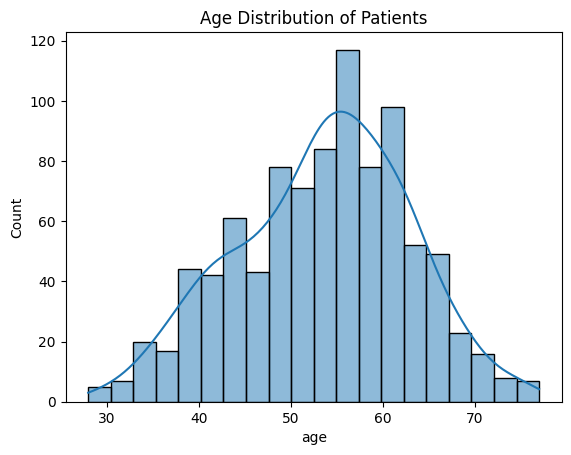

In [ ]:
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution of Patients")
plt.show()

#### AGE VS HEART DISEASE

This compares age distribution between healthy and diseased patients. It helps determine whether older patients are more likely to have heart disease.

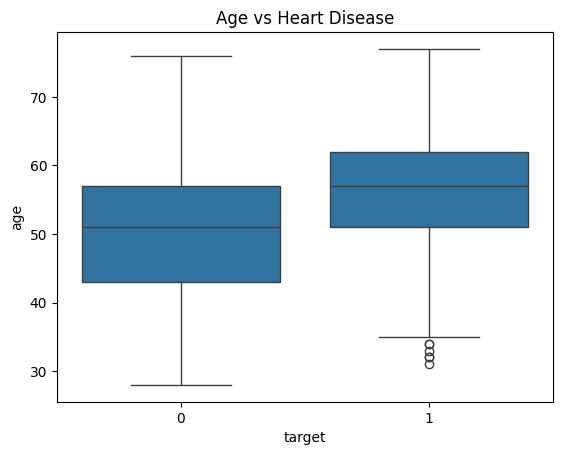

In [ ]:
sns.boxplot(x='target', y='age', data=df)
plt.title("Age vs Heart Disease")
plt.show()

#### CHEST PAIN TYPE VS HEART DISEASE (cp)

This shows the relationship between chest pain types and heart disease. Certain chest pain categories are more strongly associated with heart disease risk.

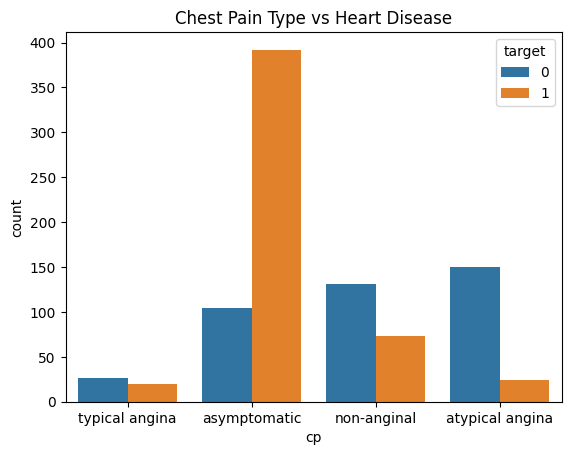

In [ ]:
sns.countplot(x='cp', hue='target', data=df)
plt.title("Chest Pain Type vs Heart Disease")
plt.show()

#### MAX HEART RATE (thalach) VS HEART DISEASE

This compares maximum heart rate between healthy and diseased patients. Lower or abnormal heart rate patterns may indicate higher risk of heart disease.

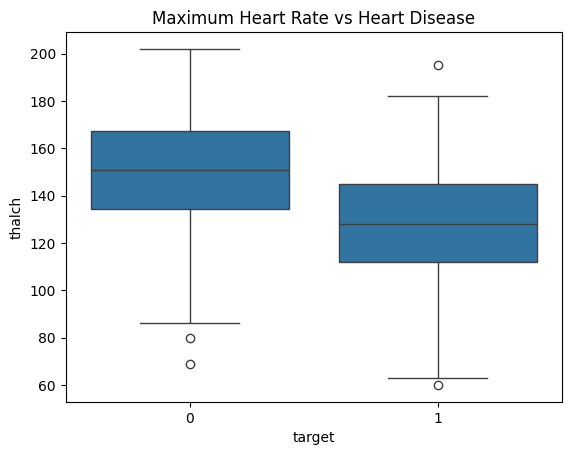

In [ ]:
sns.boxplot(x='target', y='thalch', data=df)
plt.title("Maximum Heart Rate vs Heart Disease")
plt.show()

#### CHOLESTEROL LEVEL (chol) VS HEART DISEASE

This shows whether cholesterol levels are significantly higher in patients with heart disease compared to healthy individuals.

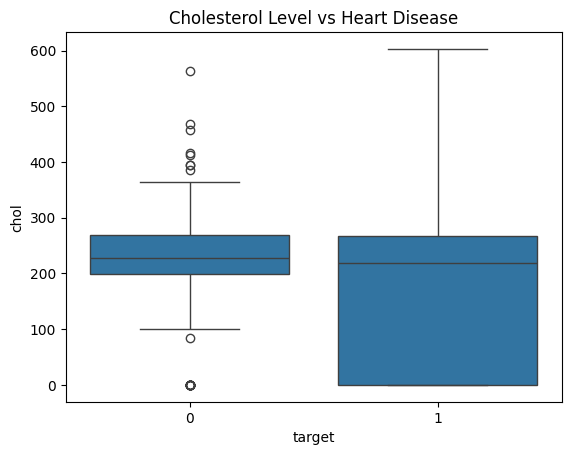

In [ ]:
sns.boxplot(x='target', y='chol', data=df)
plt.title("Cholesterol Level vs Heart Disease")
plt.show()

#### BLOOD PRESSURE (trestbps) VS HEART DISEASE

This helps determine if blood pressure is a strong predictor of heart disease in the dataset.#

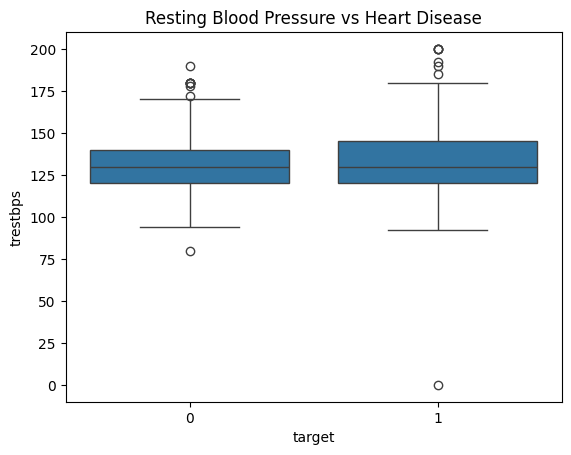

In [ ]:
sns.boxplot(x='target', y='trestbps', data=df)
plt.title("Resting Blood Pressure vs Heart Disease")
plt.show()

#### EXERCISE INDUCED ANGINA (exang)

This shows whether exercise-induced chest pain is strongly associated with heart disease presence.

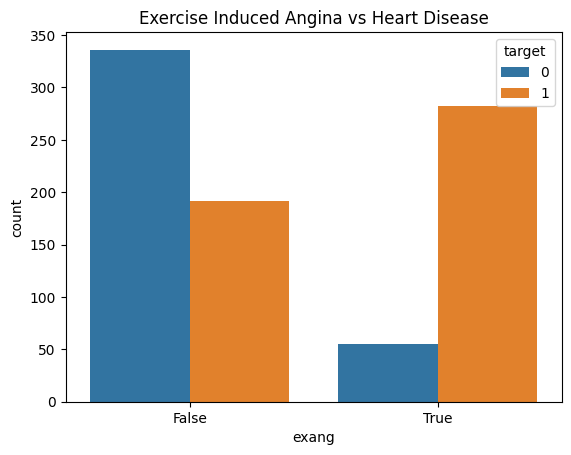

In [ ]:
sns.countplot(x='exang', hue='target', data=df)
plt.title("Exercise Induced Angina vs Heart Disease")
plt.show()

#### OLDPEAK ANALYSIS

This feature reflects heart stress during exercise. Higher values often indicate abnormal cardiac function.

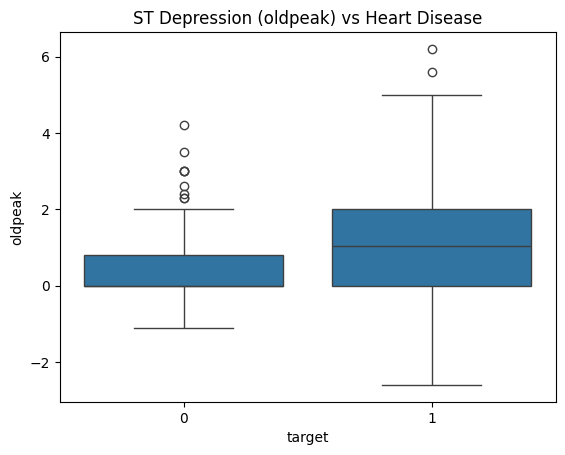

In [ ]:
sns.boxplot(x='target', y='oldpeak', data=df)
plt.title("ST Depression (oldpeak) vs Heart Disease")
plt.show()

Exploratory Data Analysis was conducted to understand the distribution and relationships of clinical features in the dataset. Visualizations such as histograms, boxplots, and correlation heatmaps were used to identify patterns associated with coronary heart disease. The analysis provides insight into how factors such as age, chest pain type, cholesterol level, and maximum heart rate contribute to heart disease prediction.

## Data Preprocessin

### Data Cleaning

#### CHECK BASIC DATA INFO

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 17 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
 16  target    920 non-null    int64  
dtypes: float64(5), int64(4), object(8)
memory usage: 122.3+ KB


,id,age,trestbps,chol,thalch,oldpeak,ca,num,target
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652,0.553261
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693,0.497426
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000,1.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000,1.000000


This dataset contains 920 patient records with 17 attributes, including demographic, clinical, and diagnostic features. Some variables are numerical (e.g., age, cholesterol), while others are categorical (e.g., chest pain type, sex, thalassemia).

The dataset contains missing values in several key clinical attributes such as ca, thal, slope, chol, trestbps, and oldpeak. These missing values must be handled carefully to avoid bias in model training.

The target variable (num) represents the presence and severity of heart disease, while the derived target column is used for binary classification (0 = no disease, 1 = disease).

#### DROP UNNECESSARY COLUMNS

In [ ]:
df = df.drop(['id', 'dataset'], axis=1)

#### CHECK MISSING VALUES

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55
exang,55
oldpeak,62


#### REPLACE "?" WITH NaN

In [ ]:
df = df.replace("?", np.nan)

#### CONVERT COLUMNS TO NUMERIC

In [ ]:
numeric_cols = ['trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,target
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,1
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,54,Female,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1,1
916,62,Male,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0,0
917,55,Male,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2,1
918,58,Male,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0,0


#### Check for missing values

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55
exang,55
oldpeak,62


#### HANDLE MISSING VALUES

We use a hybrid imputation strategy:

- Numerical → median (more robust to outliers)
- Categorical → mode

In [ ]:
for col in df.columns:
    if df[col].dtype != 'object':
        df[col].fillna(df[col].mean(), inplace=True)
    else:
        df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_9331/2695058295.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipykernel_9331/2695058295.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [ ]:
df.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,0


Missing numerical values were handled using median imputation due to the presence of outliers in the dataset. Categorical variables were filled using mode imputation to preserve distribution characteristics.

#### ENCODE CATEGORICAL VARIABLES

In [ ]:
df = pd.get_dummies(df, drop_first=True)

Categorical variables were transformed into numerical format using one-hot encoding to ensure compatibility with machine learning algorithms.

#### DEFINE TARGET

In [ ]:
y = df['target']
X = df.drop(['target', 'num'], axis=1)

#### FEATURE SCALING

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Feature scaling was applied using StandardScaler to normalize the distribution of numerical variables, ensuring that all features contribute equally to model training.

#### DATA INSIGHT

In [ ]:
df['target'].value_counts(normalize=True) * 100

,proportion
target,
1,55.326087
0,44.673913


The dataset shows a relatively balanced distribution between patients with and without heart disease, which reduces the need for heavy resampling techniques.

#### OUTLIER CHECK:

Some unrealistic values such as zero cholesterol and zero resting blood pressure were identified in the dataset. These values were treated as missing and replaced using median imputation to ensure clinical consistency.

In [ ]:
# Replace impossible values with NaN
df['chol'] = df['chol'].replace(0, np.nan)
df['trestbps'] = df['trestbps'].replace(0, np.nan)

# Re-impute again
df['chol'].fillna(df['chol'].median(), inplace=True)
df['trestbps'].fillna(df['trestbps'].median(), inplace=True)

/tmp/ipykernel_9331/100085960.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['chol'].fillna(df['chol'].median(), inplace=True)
/tmp/ipykernel_9331/100085960.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

#### FEATURE / TARGET FINAL CONFIRMATION

In [ ]:
X = df.drop(['target', 'num'], axis=1)
y = df['target']

#### SAVE THE CLEAN DATASET

After preprocessing, the cleaned dataset was saved for reproducibility and future model training. This ensures consistency between preprocessing and modeling stages.

In [ ]:
df.to_csv('cleaned_heart_disease_data.csv', index=False)

In [ ]:
# Save Scaled Features

np.save('X_scaled.npy', X_scaled)
np.save('y.npy', y)

# Modelling

In [ ]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import plot_model

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## LOADING THE PREPROCESSED DATASET

The cleaned dataset generated during the preprocessing stage is loaded for model training.

The dataset has already undergone:
- Missing value handling
- Encoding
- Feature scaling
- Cleaning of invalid values

This ensures consistency during model development.

In [ ]:
# ============================================================
# LOAD CLEANED DATASET
# ============================================================

df = pd.read_csv('Dataset/Processed Datasets/cleaned_heart_disease_data.csv')

df.head()

,age,trestbps,chol,fbs,thalch,exang,oldpeak,ca,num,target,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145.0,233.0,True,150.0,False,2.3,0.0,0,0,True,False,False,True,False,False,False,False,False,False
1,67,160.0,286.0,False,108.0,True,1.5,3.0,2,1,True,False,False,False,False,False,True,False,True,False
2,67,120.0,229.0,False,129.0,True,2.6,2.0,1,1,True,False,False,False,False,False,True,False,False,True
3,37,130.0,250.0,False,187.0,False,3.5,0.0,0,0,True,False,True,False,True,False,False,False,True,False
4,41,130.0,204.0,False,172.0,False,1.4,0.0,0,0,False,True,False,False,False,False,False,True,True,False


In [ ]:
# ============================================================
# FEATURES AND TARGET
# ============================================================

X = df.drop(['target', 'num'], axis=1)
y = df['target']

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (920, 18)
Target Shape: (920,)


## FEATURE SCALING

Feature scaling is applied to normalize numerical values so that all features contribute equally during model training.

This is especially important for:
- Logistic Regression
- Support Vector Machine (SVM)
- Artificial Neural Networks (ANN)

StandardScaler was used to standardize the dataset by removing the mean and scaling to unit variance.

In [ ]:
# ============================================================
# FEATURE SCALING
# ============================================================

from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Scale Features
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

print("Feature Scaling Completed")

Feature Scaling Completed


In [ ]:
# ============================================================
# SAVE SCALER
# ============================================================

joblib.dump(scaler, 'Utils/scaler.pkl')

print("Scaler Saved Successfully")

Scaler Saved Successfully


In [ ]:
print("Feature Shape:", X_scaled.shape)
print("Target Shape:", y.shape)

Feature Shape: (920, 18)
Target Shape: (920,)


# TRAIN-TEST SPLIT

The dataset is divided into:
- 80% Training Data
- 20% Testing Data

This allows the models to learn from training data and later be evaluated on unseen data.

In [ ]:
# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 736
Testing Samples: 184


## LOGISTIC REGRESSION MODEL

Logistic Regression is used as a baseline classification model due to:
- Simplicity
- Interpretability
- Strong performance in binary classification problems

In [ ]:
# ============================================================
# LOGISTIC REGRESSION
# ============================================================

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

print("Logistic Regression Training Completed")

Logistic Regression Training Completed


In [ ]:
# ============================================================
# SAVE LOGISTIC REGRESSION MODEL
# ============================================================

joblib.dump(log_model, 'Utils/logistic_regression_model.pkl')

print("Model Saved Successfully")

Model Saved Successfully


# SUPPORT VECTOR MACHINE (SVM)

Support Vector Machine is used because of its effectiveness in handling:
- High-dimensional data
- Complex decision boundaries
- Binary classification tasks

In [ ]:
# ============================================================
# SVM MODEL
# ============================================================

svm_model = SVC(
    kernel='rbf',
    probability=True
)

svm_model.fit(X_train, y_train)

print("SVM Training Completed")

SVM Training Completed


In [ ]:
# ============================================================
# SAVE SVM MODEL
# ============================================================

joblib.dump(svm_model, 'Utils/svm_model.pkl')

print("SVM Model Saved")

SVM Model Saved


# RANDOM FOREST MODEL

Random Forest is an ensemble learning algorithm that combines multiple decision trees.

Advantages:
- Handles nonlinear relationships
- Reduces overfitting
- Strong predictive performance

In [ ]:
# ============================================================
# RANDOM FOREST MODEL
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Training Completed")

Random Forest Training Completed


In [ ]:
# ============================================================
# SAVE RANDOM FOREST MODEL
# ============================================================

joblib.dump(rf_model, 'Utils/random_forest_model.pkl')

print("Random Forest Model Saved")

Random Forest Model Saved


# ARTIFICIAL NEURAL NETWORK (ANN)

Artificial Neural Networks are capable of learning complex nonlinear relationships in clinical datasets.

The ANN architecture used in this project contains:
- Input Layer
- Hidden Layers
- Dropout Regularization
- Output Layer

In [ ]:
# ============================================================
# ANN MODEL
# ============================================================

ann_model = Sequential()

# Input + Hidden Layer
ann_model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))

# Dropout
ann_model.add(Dropout(0.3))

# Hidden Layer
ann_model.add(Dense(32, activation='relu'))

# Dropout
ann_model.add(Dropout(0.3))

# Output Layer
ann_model.add(Dense(1, activation='sigmoid'))

# Compile Model
ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

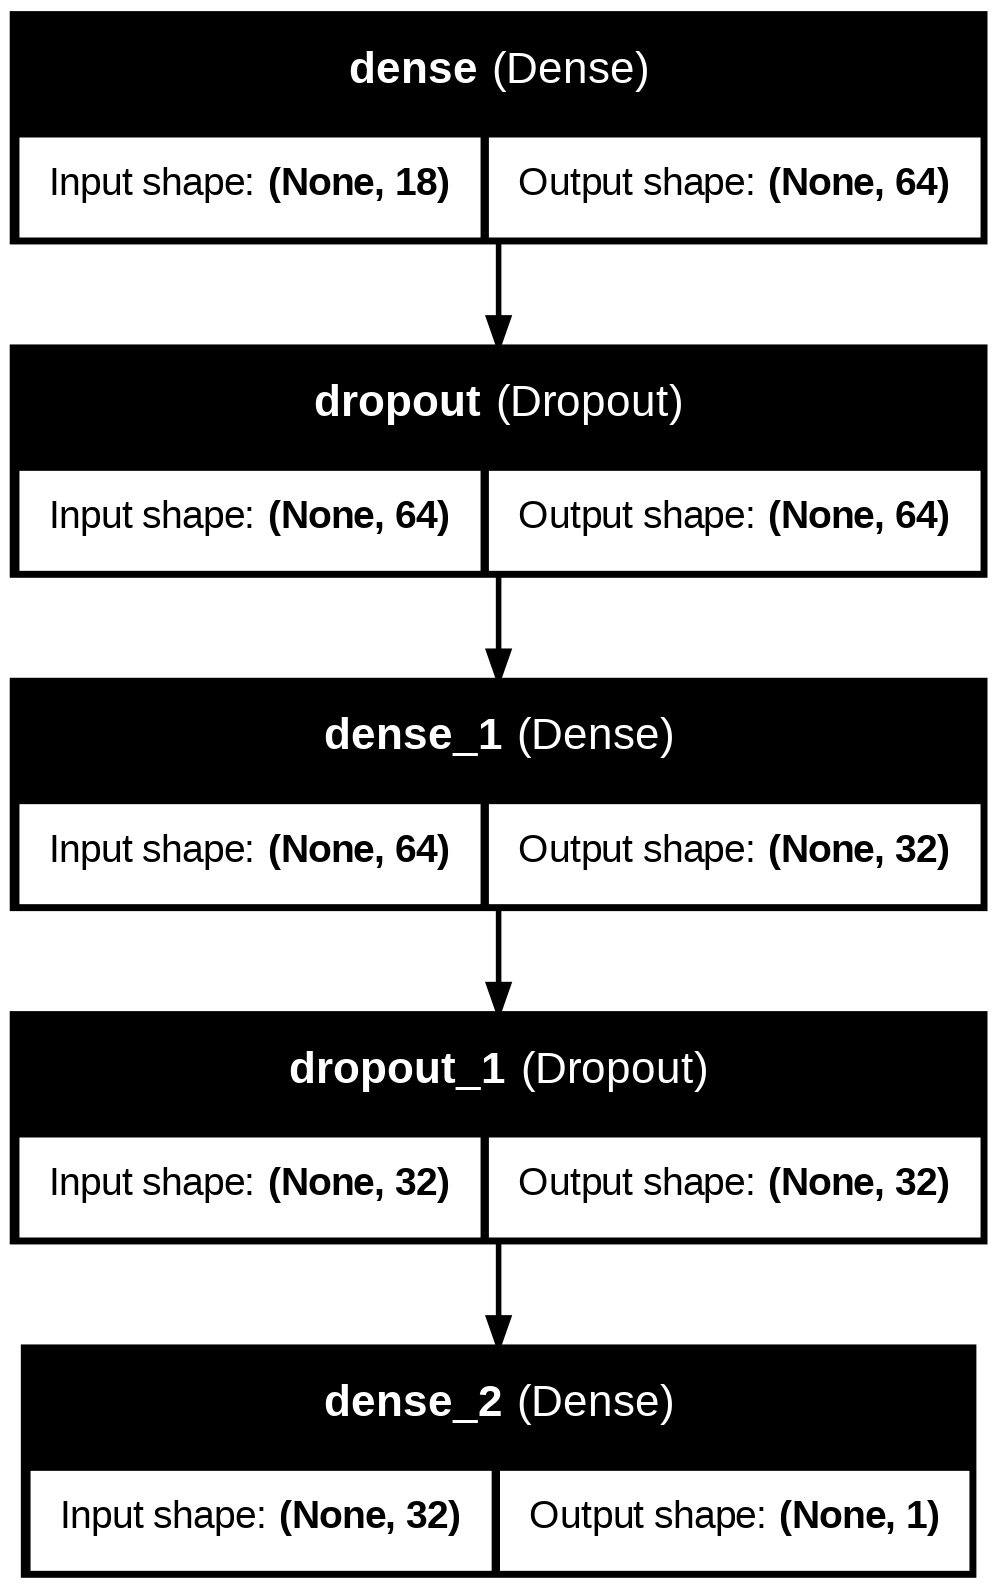

In [ ]:
# ============================================================
# VISUALIZE ANN ARCHITECTURE
# ============================================================

plot_model(
    ann_model,
    show_shapes=True,
    show_layer_names=True,
    to_file='Plots/ann_model_structure.png'
)

from IPython.display import Image
Image('Plots/ann_model_structure.png')

### TRAINING THE ANN MODEL

The model is trained for multiple epochs to allow the network learn patterns from the dataset.

In [ ]:
# ============================================================
# TRAIN ANN
# ============================================================

history = ann_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.5952 - loss: 0.6655 - val_accuracy: 0.7770 - val_loss: 0.5965
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6922 - loss: 0.5942 - val_accuracy: 0.8311 - val_loss: 0.5288
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7483 - loss: 0.5434 - val_accuracy: 0.8378 - val_loss: 0.4743
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8027 - loss: 0.4701 - val_accuracy: 0.8446 - val_loss: 0.4366
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8027 - loss: 0.4614 - val_accuracy: 0.8378 - val_loss: 0.4108
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7874 - loss: 0.4463 - val_accuracy: 0.8446 - val_loss: 0.4019
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7942 - loss: 0.4447 - val_accuracy: 0.8514 - val_loss: 0.3985
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8231 - loss: 0.4269 - val_accuracy: 0.8378 - val_l

## TRAINING LOSS CURVE

This graph shows how the training and validation loss changed during training.

A decreasing loss indicates that the model is learning effectively.

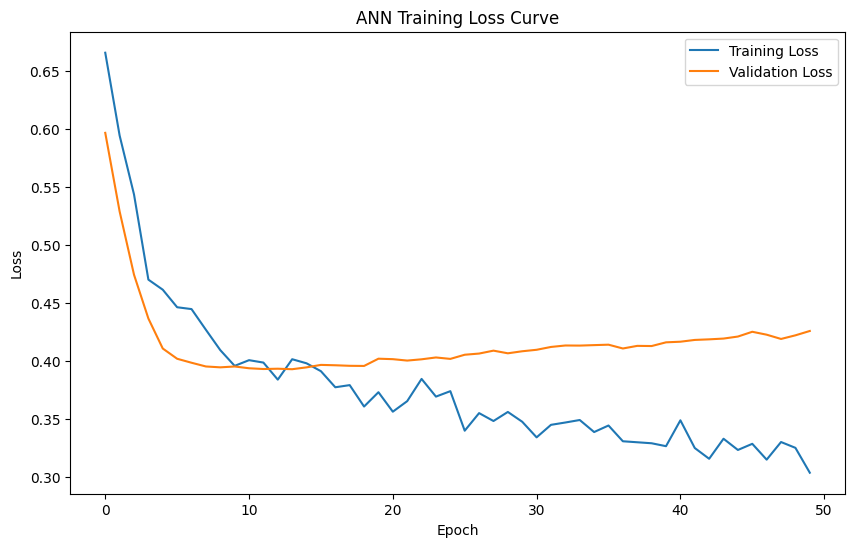

In [ ]:
# ============================================================
# LOSS CURVE
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ANN Training Loss Curve')

plt.legend()

plt.show()

## TRAINING ACCURACY CURVE

This graph shows how the model accuracy improved during training.

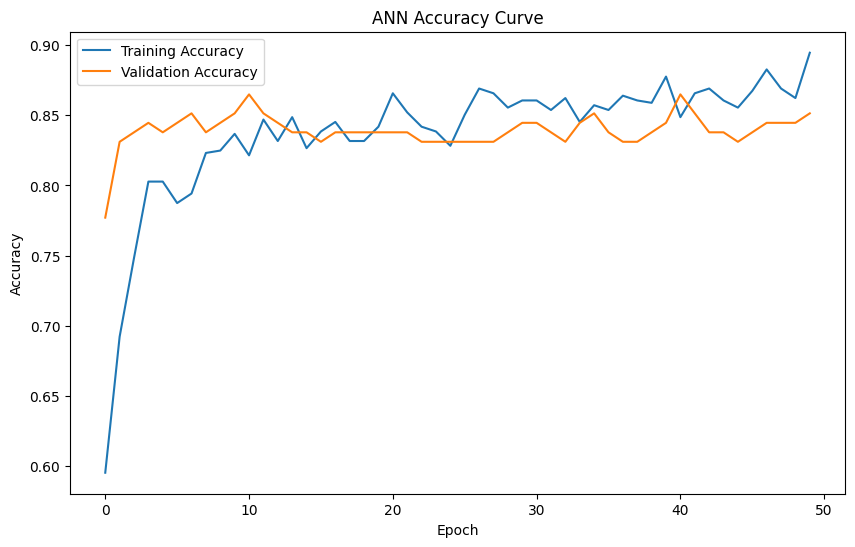

In [ ]:
# ============================================================
# ACCURACY CURVE
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.title('ANN Accuracy Curve')

plt.legend()

plt.show()

In [ ]:
# ============================================================
# SAVE ANN MODEL
# ============================================================

ann_model.save('Utils/ann_model.h5')

print("ANN Model Saved Successfully")

ANN Model Saved Successfully


# Model Evaluation

### Load Trained Models

In [ ]:
dir

Data\ Preprocessing\ Milstone\ Documentation\ (Milestone\ 1).docx  Notebooks
Dataset								   Plots
Detailed_Milestone_2_Model_Development_Report.docx		   Utils


In [ ]:
import joblib
from tensorflow.keras.models import load_model

lr_model = joblib.load('./Utils/logistic_regression_model.pkl')
svm_model = joblib.load('Utils/svm_model.pkl')
rf_model = joblib.load('Utils/random_forest_model.pkl')
ann_model = load_model('Utils/ann_model.h5')

### Create Evaluation Folder

In [ ]:
import os

os.makedirs("/content/Plots/Evaluation_Plots", exist_ok=True)

### Generate Predictions

In [ ]:
models = {
    "Logistic Regression": lr_model,
    "SVM": svm_model,
    "Random Forest": rf_model
}

results = {}

for name, model in models.items():

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = model.decision_function(X_test)

    results[name] = {
        "pred": y_pred,
        "prob": y_prob
    }

#### ANN Predictions

In [ ]:
ann_prob = ann_model.predict(X_test)

ann_pred = (ann_prob > 0.5).astype(int)

results["ANN"] = {
    "pred": ann_pred.flatten(),
    "prob": ann_prob.flatten()
}

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


### Evaluation Metrics

Proposal specifically mentioned:

Accuracy
Precision
Recall
F1 Score
ROC-AUC

So we calculate all.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

evaluation_results = []

for model_name, result in results.items():

    y_pred = result["pred"]
    y_prob = result["prob"]

    evaluation_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob)
    })

#### Model Comparison Table

In [ ]:
import pandas as pd

evaluation_df = pd.DataFrame(evaluation_results)

evaluation_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.804348,0.805556,0.852941,0.828571,0.892635
1,SVM,0.826087,0.801724,0.911765,0.853211,0.906743
2,Random Forest,0.842391,0.828829,0.901961,0.863850,0.907819
3,ANN,0.831522,0.814159,0.901961,0.855814,0.899330


In [ ]:
evaluation_df.to_csv(
    "Utils/model_comparison.csv",
    index=False
)

#### Save Model Comparison Plot

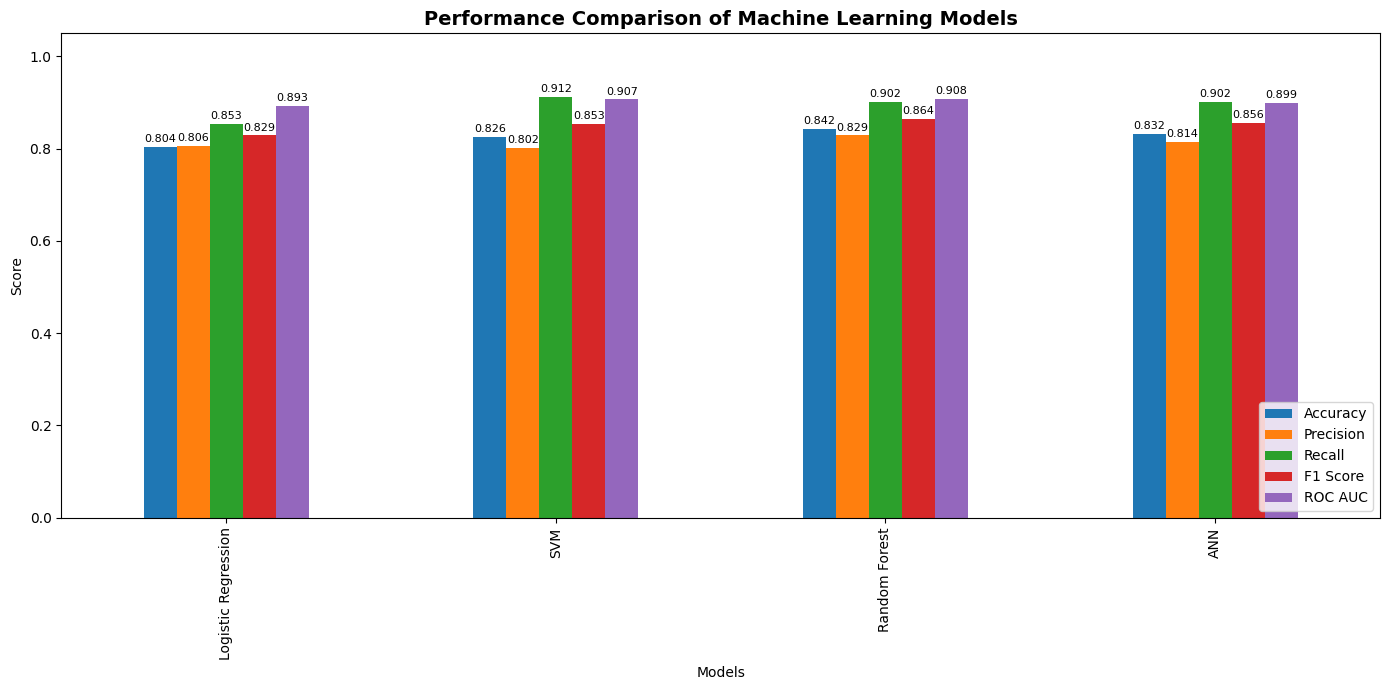

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = evaluation_df.set_index("Model")

ax = plot_df.plot(
    kind='bar',
    figsize=(14,7)
)

plt.title(
    "Performance Comparison of Machine Learning Models",
    fontsize=14,
    fontweight='bold'
)

plt.ylabel("Score")
plt.xlabel("Models")
plt.ylim(0, 1.05)

# Add value labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.3f',
        fontsize=8,
        padding=2
    )

plt.legend(
    loc='lower right'
)

plt.tight_layout()

plt.savefig(
    project_path + "/Plots/Evaluation_Plots/model_comparison_with_values.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

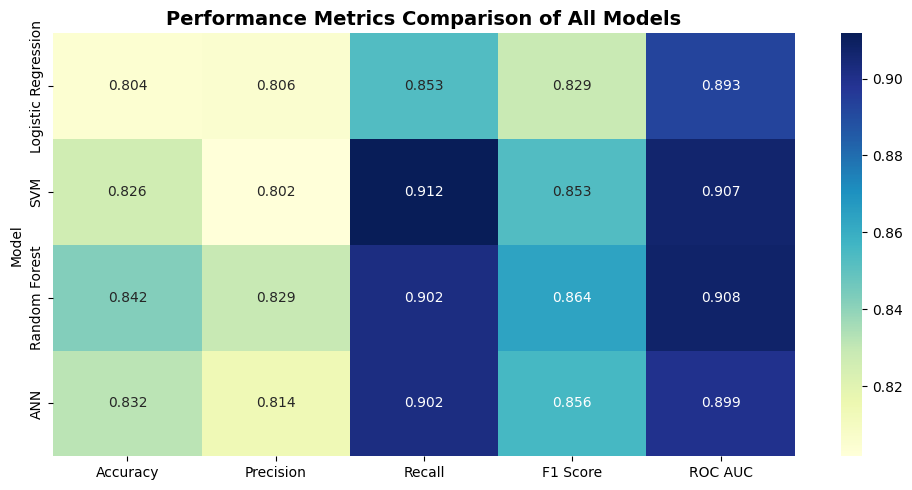

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_df = evaluation_df.set_index("Model")

plt.figure(figsize=(10,5))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu"
)

plt.title(
    "Performance Metrics Comparison of All Models",
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    project_path + "/Plots/Evaluation_Plots/model_performance_heatmap.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

#### Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

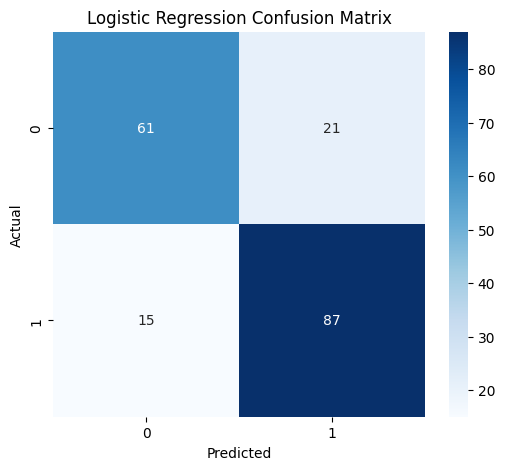

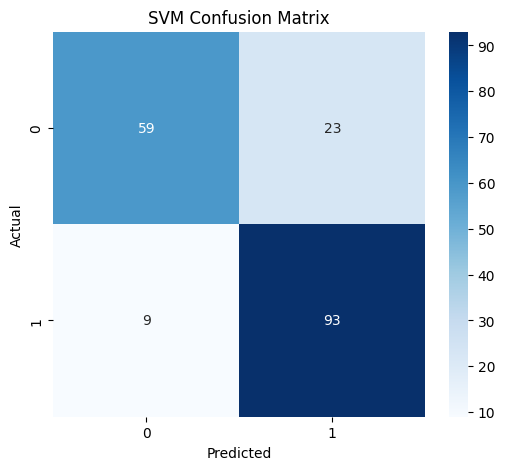

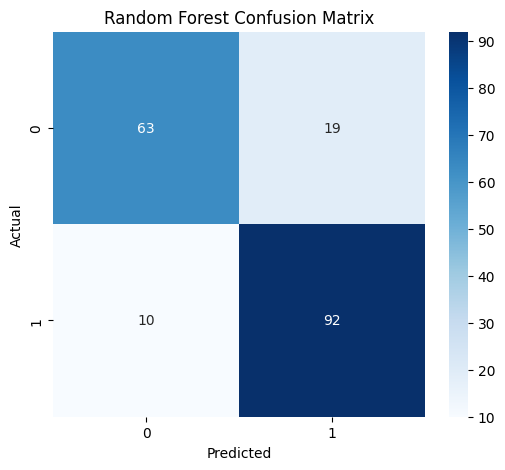

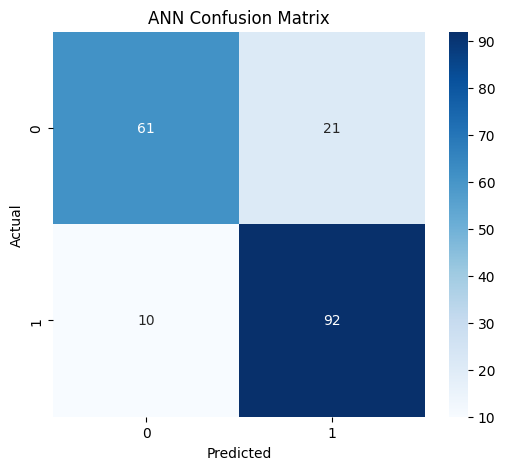

In [ ]:
for model_name, result in results.items():

    cm = confusion_matrix(y_test, result["pred"])

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f"{model_name} Confusion Matrix")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.savefig(
        project_path + f"Plots/Evaluation_Plots/{model_name}_confusion_matrix.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

#### Classification Report Image

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
for model_name, result in results.items():

    report = classification_report(
        y_test,
        result["pred"]
    )

    fig = plt.figure(figsize=(10,6))

    plt.text(
        0.01,
        0.05,
        report,
        {'fontsize':12},
        fontfamily='monospace'
    )

    plt.axis('off')

    plt.savefig(
        project_path + f"/Plots/Evaluation_Plots/{model_name}_classification_report.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.close()

#### ROC Curve

In [ ]:
from sklearn.metrics import roc_curve

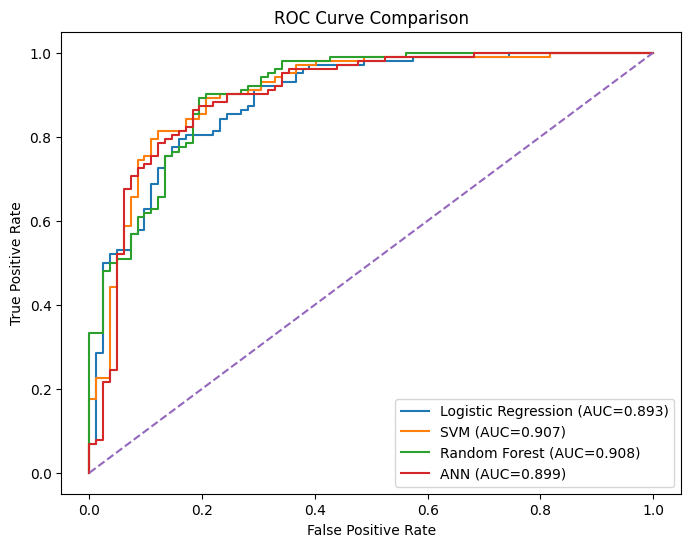

In [ ]:
plt.figure(figsize=(8,6))

for model_name, result in results.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        result["prob"]
    )

    auc_score = roc_auc_score(
        y_test,
        result["prob"]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC={auc_score:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.savefig(
    project_path + "/Plots/Evaluation_Plots/roc_curve_comparison.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

#### Precision Recall Curve

In [ ]:
from sklearn.metrics import precision_recall_curve

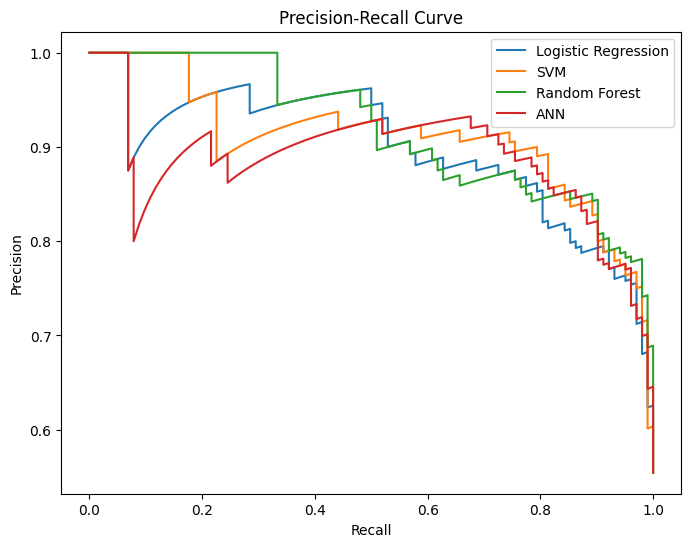

In [ ]:
plt.figure(figsize=(8,6))

for model_name, result in results.items():

    precision, recall, _ = precision_recall_curve(
        y_test,
        result["prob"]
    )

    plt.plot(
        recall,
        precision,
        label=model_name
    )

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.legend()

plt.savefig(
    project_path + "/Plots/Evaluation_Plots/precision_recall_curve.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

#### Feature Importance (Random Forest)

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

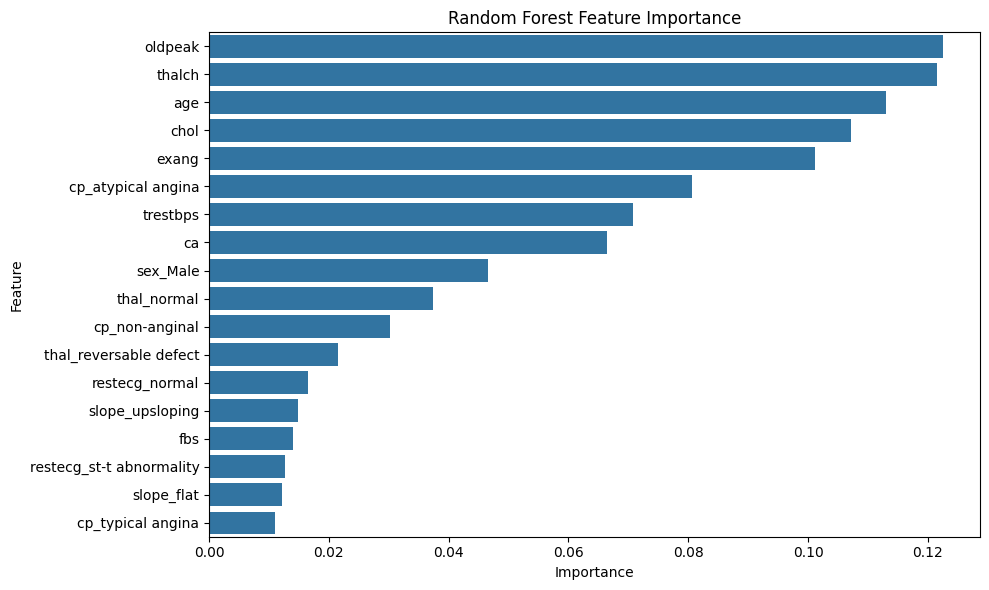

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title(
    "Random Forest Feature Importance"
)

plt.tight_layout()

plt.savefig(
    project_path + "Plots/Evaluation_Plots/random_forest_feature_importance.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Web Visualizer

In [1]:
from google.colab import userdata

In [ ]:
!pip install streamlit pyngrok

In [3]:
ngrok_key = userdata.get("ngrock_api_key")

In [4]:
from pyngrok import ngrok

# Paste your ngrok auth token here
ngrok.set_auth_token(ngrok_key)

In [12]:
from pyngrok import ngrok
import subprocess, time

# 1. Kill old tunnels
ngrok.kill()

# 2. Start Streamlit app in the background
process = subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501"])

# 3. Give Streamlit a few seconds to spin up
time.sleep(5)

# 4. Open ngrok tunnel to port 8501
public_url = ngrok.connect(8501)
print("Streamlit app URL:", public_url)

Streamlit app URL: NgrokTunnel: "https://80e3-136-110-3-233.ngrok-free.app" -> "http://localhost:8501"
